In [ ]:
import sys
import pandapower as pp
import pandapower.networks as nw
import pandas as pd
import nbformat
import matplotlib.pyplot as plt
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly
import copy
import pandapower as pp
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly


net = pp.networks.create_cigre_network_mv(with_der=False)


net.load['p_mw']= net.load['p_mw'] / 2
net.load['q_mvar']= net.load['q_mvar'] / 2

pp.runpp(net)
# print(net.load)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


         name  bus      p_mw    q_mvar  const_z_percent  const_i_percent  \
0     Load R1    1  7.497000  1.522331              0.0              0.0   
1     Load R3    3  0.138225  0.034642              0.0              0.0   
2     Load R4    4  0.215825  0.054091              0.0              0.0   
3     Load R5    5  0.363750  0.091164              0.0              0.0   
4     Load R6    6  0.274025  0.068677              0.0              0.0   
5     Load R8    8  0.293425  0.073539              0.0              0.0   
6    Load R10   10  0.237650  0.059561              0.0              0.0   
7    Load R11   11  0.164900  0.041328              0.0              0.0   
8    Load R12   12  7.497000  1.522331              0.0              0.0   
9    Load R14   14  0.104275  0.026134              0.0              0.0   
10   Load CI1    1  2.422500  0.796237              0.0              0.0   
11   Load CI3    3  0.112625  0.069799              0.0              0.0   
12   Load CI

# Step 3.1 Vehicle SOC


Processing schedule_Airmee ...
  Tested 1 chargers -> success=False, unmet=2160.341 kWh
  Tested 2 chargers -> success=False, unmet=215.641 kWh
  Tested 3 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 3


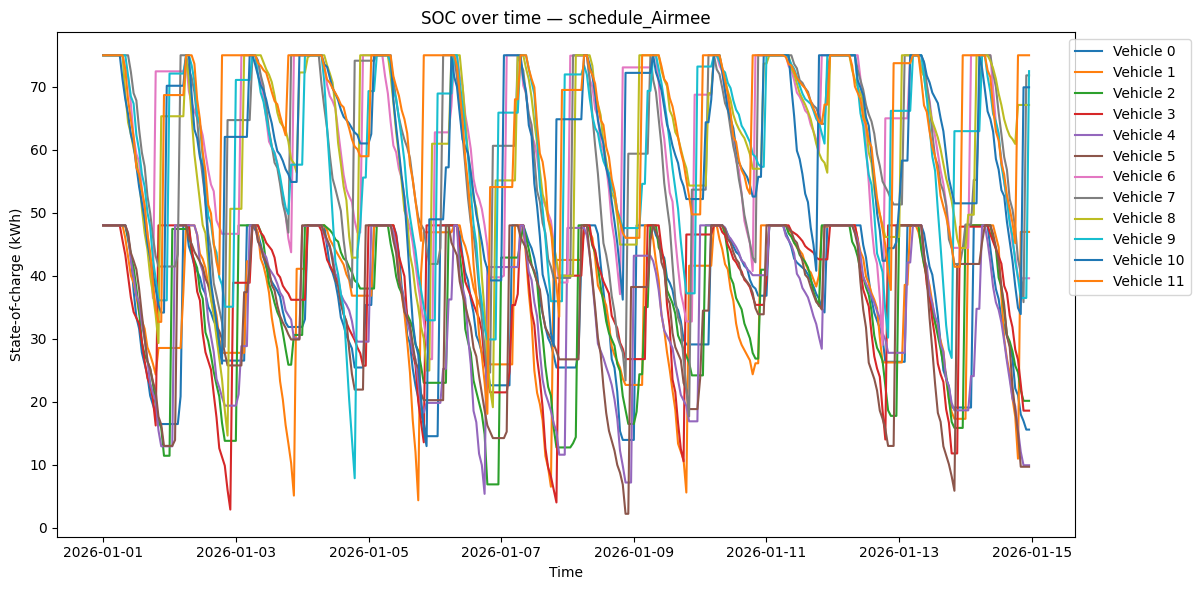

Processing schedule_Postnord ...
  Tested 1 chargers -> success=False, unmet=9524.770 kWh
  Tested 2 chargers -> success=False, unmet=7144.873 kWh
  Tested 3 chargers -> success=False, unmet=4841.955 kWh
  Tested 4 chargers -> success=False, unmet=2753.724 kWh
  Tested 5 chargers -> success=False, unmet=1080.423 kWh
  Tested 6 chargers -> success=False, unmet=257.245 kWh
  Tested 7 chargers -> success=False, unmet=92.444 kWh
  Tested 8 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 8


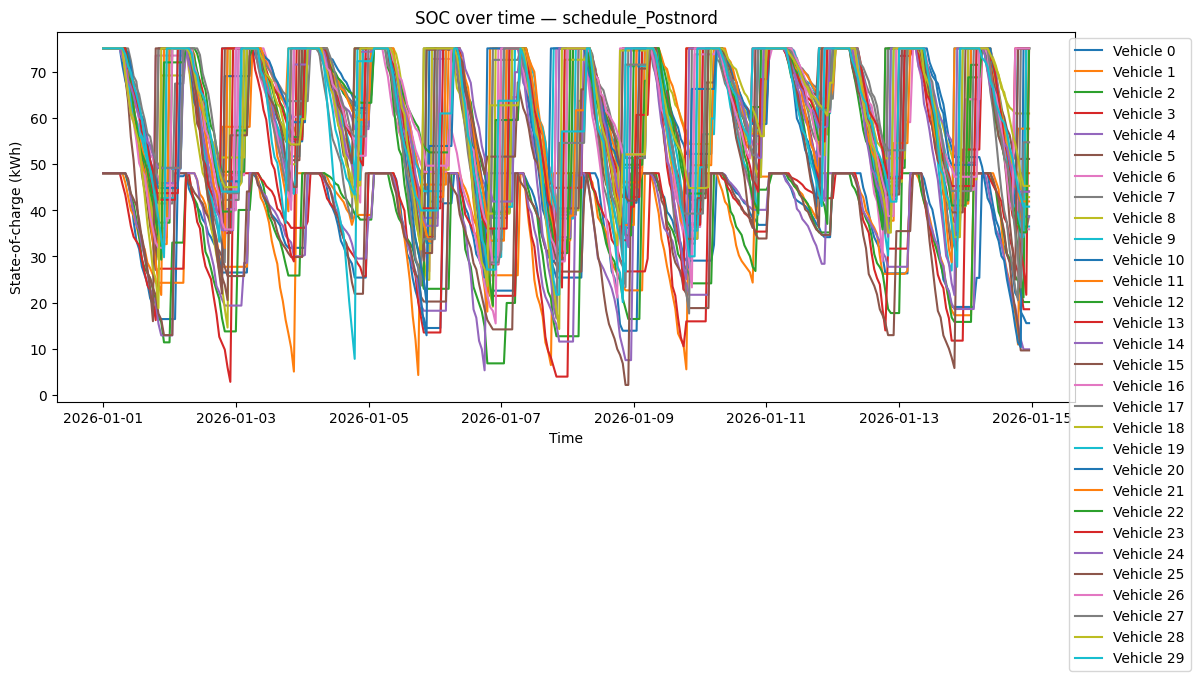

Processing schedule_Mathem ...
  Tested 1 chargers -> success=False, unmet=3378.744 kWh
  Tested 2 chargers -> success=False, unmet=864.207 kWh
  Tested 3 chargers -> success=False, unmet=18.426 kWh
  Tested 4 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 4


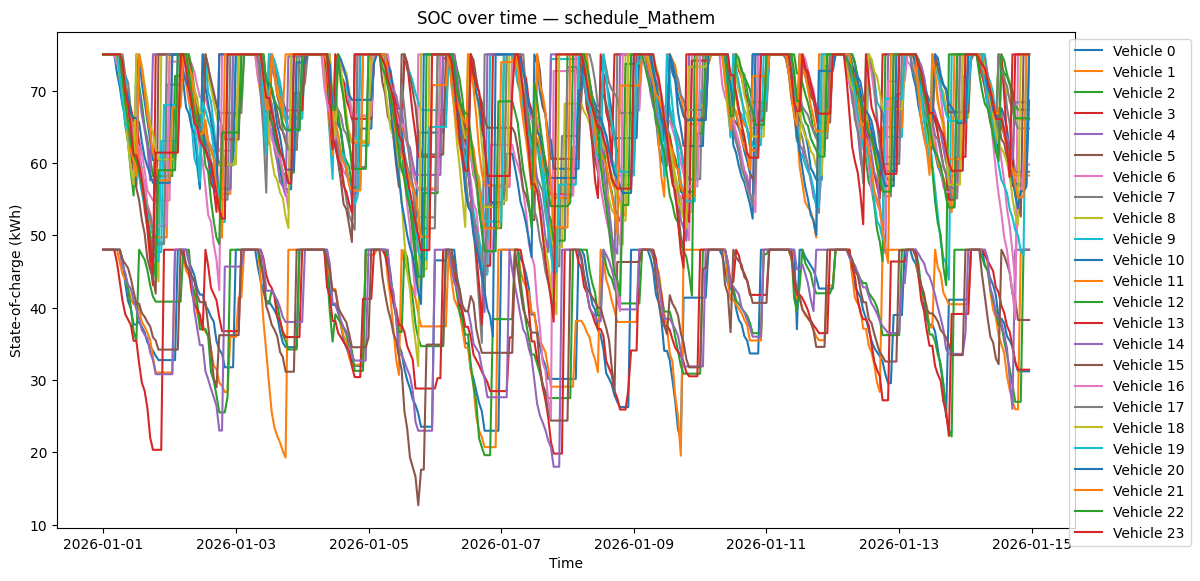

Processing schedule_ICA ...
  Tested 1 chargers -> success=False, unmet=845.608 kWh
  Tested 2 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 2


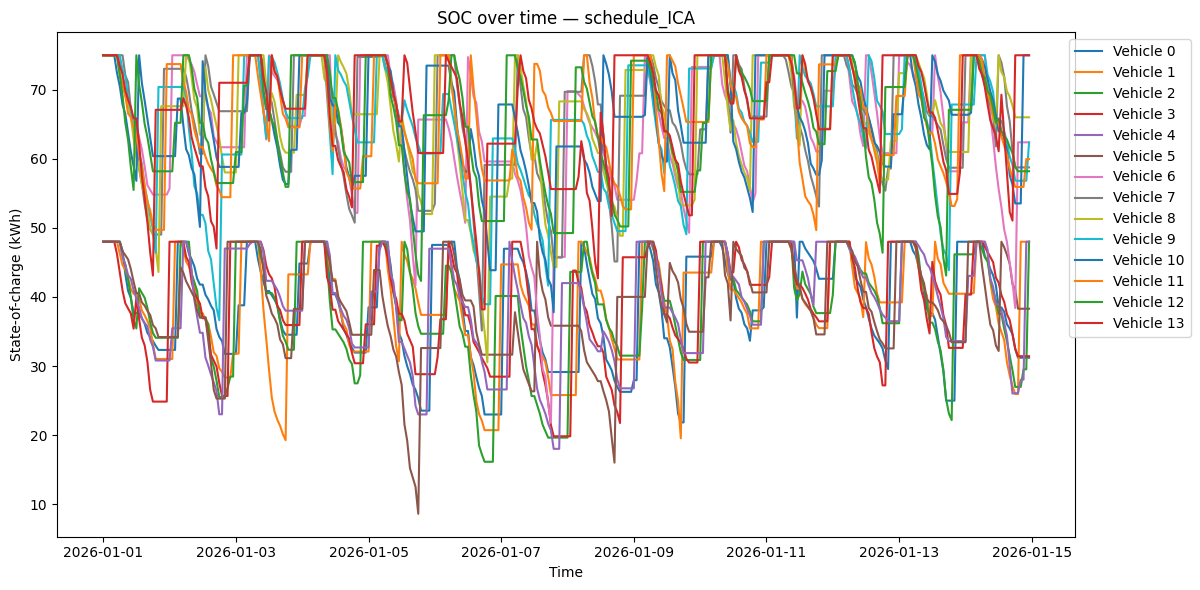


Summary:
 schedule_Airmee: 3  (ok)
 schedule_Postnord: 8  (ok)
 schedule_Mathem: 4  (ok)
 schedule_ICA: 2  (ok)


In [23]:
import pandas as pd
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt

# -------------------------
# Config / assumptions
# -------------------------
notebook_dir = Path(os.getcwd())
base_path = notebook_dir.parent / "data" / "Output"

# Vehicle inlet rates (kW) and battery capacities (kWh)
vehicle_charging_limits = {"Renault": 80.0, "Toyota": 100.0}
battery_capacities = {"Renault": 48.0, "Toyota": 75.0}

# Use Fast AC only: charger assumed capacity (kW). Change if your charger physical rating differs.
FAST_AC_CAPACITY_KW = 12

# Shops (folders contain shop.csv). Adjust names if necessary.
shops = ["schedule_Airmee", "schedule_Postnord", "schedule_Mathem", "schedule_ICA"]

# Maximum number of chargers to test (safety cap). Usually you won't need more chargers than vehicles.
MAX_CHARGERS_TO_TEST = 20

# -------------------------
# Helper: simulate week with m chargers for one shop
# -------------------------
def simulate_shop(file_path, m_chargers, debug=False):
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())

    # Vehicle type mapping
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()

    # Precompute inlet per vehicle
    inlet = {vid: vehicle_charging_limits.get(vehicle_types.get(vid), FAST_AC_CAPACITY_KW) for vid in vehicles}

    # --- FIX: dummy depot night before week starts ---
    # Start every vehicle with its full battery
    SOC = {}
    for vid in vehicles:
        vtype = vehicle_types.get(vid, None)
        cap = battery_capacities.get(vtype, 48.0)  # fallback = 48
        SOC[vid] = cap

    # Traces
    soc_trace = {vid: [] for vid in vehicles}
    time_trace = []

    unmet_energy_total = 0.0

    # --- main simulation loop ---
    for ts in timestamps:
        df_h = df[df['date'] == ts]

        # Apply driving consumption
        for _, row in df_h.iterrows():
            vid = row['VehicleID']
            cons = float(row.get('Consumption_kWh', 0.0))
            prev_soc = SOC.get(vid, 0.0)
            new_soc = prev_soc - cons
            if new_soc < -1e-9:
                unmet = -new_soc
                unmet_energy_total += unmet
                SOC[vid] = 0.0
            else:
                SOC[vid] = new_soc

        # Charging when at depot
        depot_rows = df_h[df_h['Location'] == 1]
        present_vids = depot_rows['VehicleID'].unique().tolist()
        available_energy = m_chargers * FAST_AC_CAPACITY_KW  # 1h window

        needs = []
        for vid in present_vids:
            vtype = vehicle_types.get(vid)
            cap = battery_capacities.get(vtype, 48.0)
            need = max(0.0, cap - SOC.get(vid, 0.0))
            max_accept = inlet.get(vid, FAST_AC_CAPACITY_KW)
            if need > 1e-9:
                needs.append({'vid': vid, 'need': need, 'max_accept': max_accept})

        needs.sort(key=lambda x: x['need'], reverse=True)
        for n in needs:
            if available_energy <= 1e-9:
                break
            take = min(n['need'], n['max_accept'], available_energy)
            SOC[n['vid']] += take
            available_energy -= take

        for vid in vehicles:
            soc_trace[vid].append(SOC.get(vid, 0.0))
        time_trace.append(ts)

    success = (unmet_energy_total <= 1e-6)
    trace = {"time": time_trace, "soc_trace": soc_trace, "unmet_energy_total": unmet_energy_total}
    return success, trace


# -------------------------
# Find minimal chargers per shop using incremental search
# -------------------------
def find_min_chargers_for_shop(file_path, max_chargers=MAX_CHARGERS_TO_TEST, debug=False):
    # Try m = 1..max_chargers
    for m in range(1, max_chargers + 1):
        success, trace = simulate_shop(file_path, m, debug=debug)
        print(f"  Tested {m} chargers -> success={success}, unmet={trace['unmet_energy_total']:.3f} kWh")
        if debug:
            print(f"Tested {m} chargers -> success={success}, unmet={trace['unmet_energy_total']:.3f} kWh")
        if success:
            return m, trace
    # if we reach here, not feasible with tested chargers
    return None, None

# -------------------------
# Plotting: SOC time series per vehicle
# -------------------------
def plot_soc(trace, file_path, shop_name, save_fig=False):
    time = trace['time']
    soc = trace['soc_trace']

    plt.figure(figsize=(12, 6))
    for vid, series in soc.items():
        plt.plot(time, series, label=f"Vehicle {vid}")
    plt.xlabel("Time")
    plt.ylabel("State-of-charge (kWh)")
    plt.title(f"SOC over time — {shop_name}")
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
    plt.tight_layout()
    if save_fig:
        out = Path(file_path).with_suffix('.png')
        plt.savefig(out, dpi=150)
        print("Saved figure to", out)
    plt.show()

# -------------------------
# Run for all shops
# -------------------------
if __name__ == "__main__":
    results = {}
    for shop in shops:
        shop_folder = base_path / shop
        file = shop_folder / f"{shop}.csv"
        if not file.exists():
            print(f"[WARN] file not found: {file}")
            results[shop] = {'min_chargers': None, 'reason': 'file_missing'}
            continue

        print(f"Processing {shop} ...")
        min_ch, trace = find_min_chargers_for_shop(file, max_chargers=MAX_CHARGERS_TO_TEST, debug=False)

        if min_ch is None:
            print(f"  -> Not feasible with up to {MAX_CHARGERS_TO_TEST} chargers.")
            results[shop] = {'min_chargers': None, 'reason': 'not_feasible'}
        else:
            print(f"  -> Minimum chargers required: {min_ch}")
            results[shop] = {'min_chargers': min_ch, 'trace': trace}
            # plot SOC trace (you can set save_fig=True to write png)
            plot_soc(trace, file, shop, save_fig=False)

    print("\nSummary:")
    for shop, info in results.items():
        print(f" {shop}: {info.get('min_chargers')}  ({info.get('reason','ok')})")


# Comparison of Different Chargers
Here I will compare 4 different charger speed for all shops 

COMPREHENSIVE CHARGER TYPE ANALYSIS

Testing Charger Type: Category 1 (7 kW)
  ICA: 3 chargers needed
  Mathem: 6 chargers needed
  Postnord: 15 chargers needed
  Airmee: 6 chargers needed

  Running power flow simulations...
    Progress: 0/336 timesteps
    Progress: 48/336 timesteps
    Progress: 96/336 timesteps
    Progress: 144/336 timesteps
    Progress: 192/336 timesteps
    Progress: 240/336 timesteps
    Progress: 288/336 timesteps

  Worst case line loading: 62.24%
  Worst case occurs at: 2026-01-02 20:00:00+01:00 on line_1

  Performing N-1 contingency analysis at worst case...
    Line loading violations: 8
    Trafo loading violations: 0
    Bus voltage violations (1.1/0.9): 0
    Bus voltage violations (1.05/0.95): 49

Testing Charger Type: Medium Charger (15 kW)
  ICA: 2 chargers needed
  Mathem: 3 chargers needed
  Postnord: 7 chargers needed
  Airmee: 3 chargers needed

  Running power flow simulations...
    Progress: 0/336 timesteps
    Progress: 48/336 timesteps
  

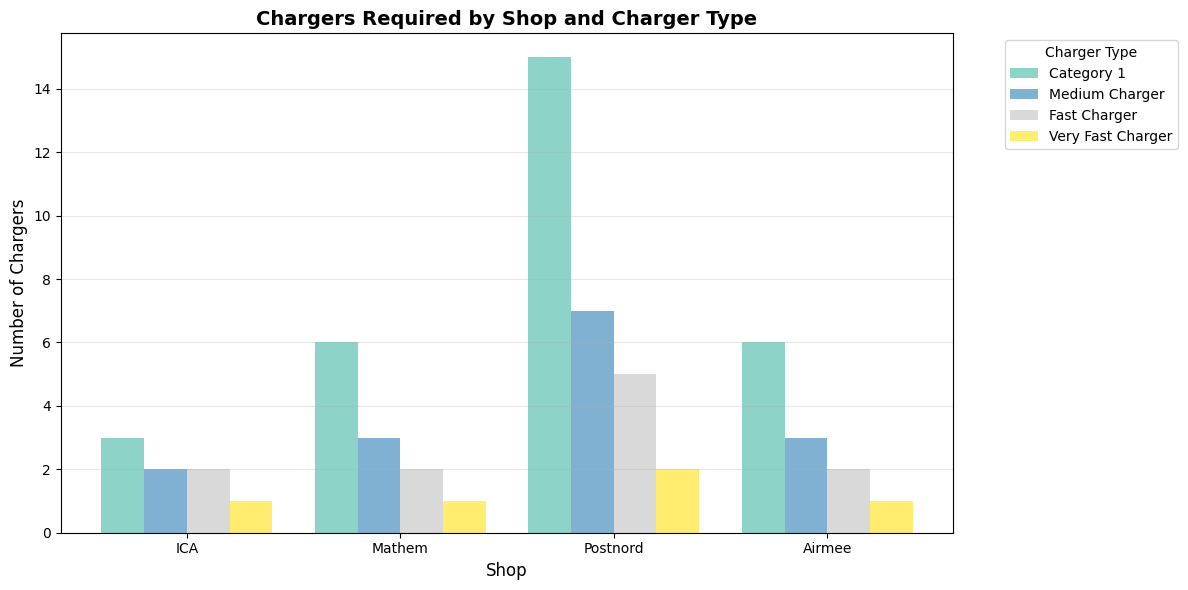

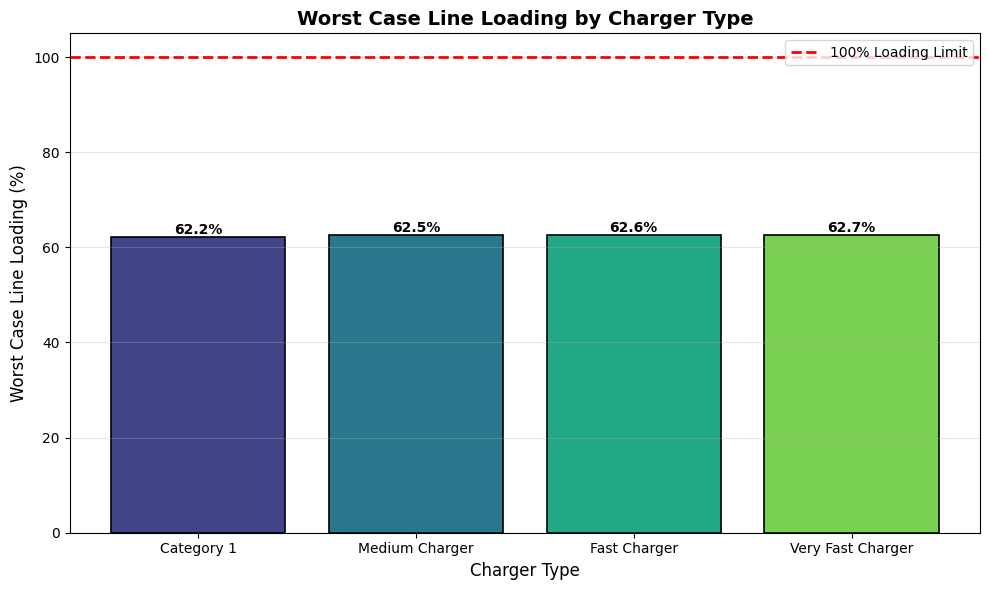

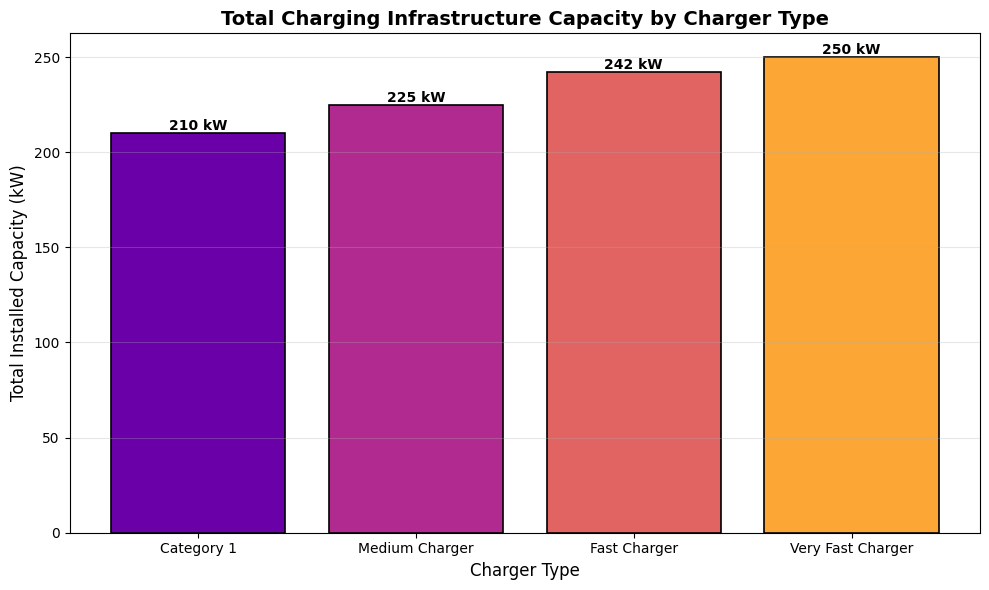

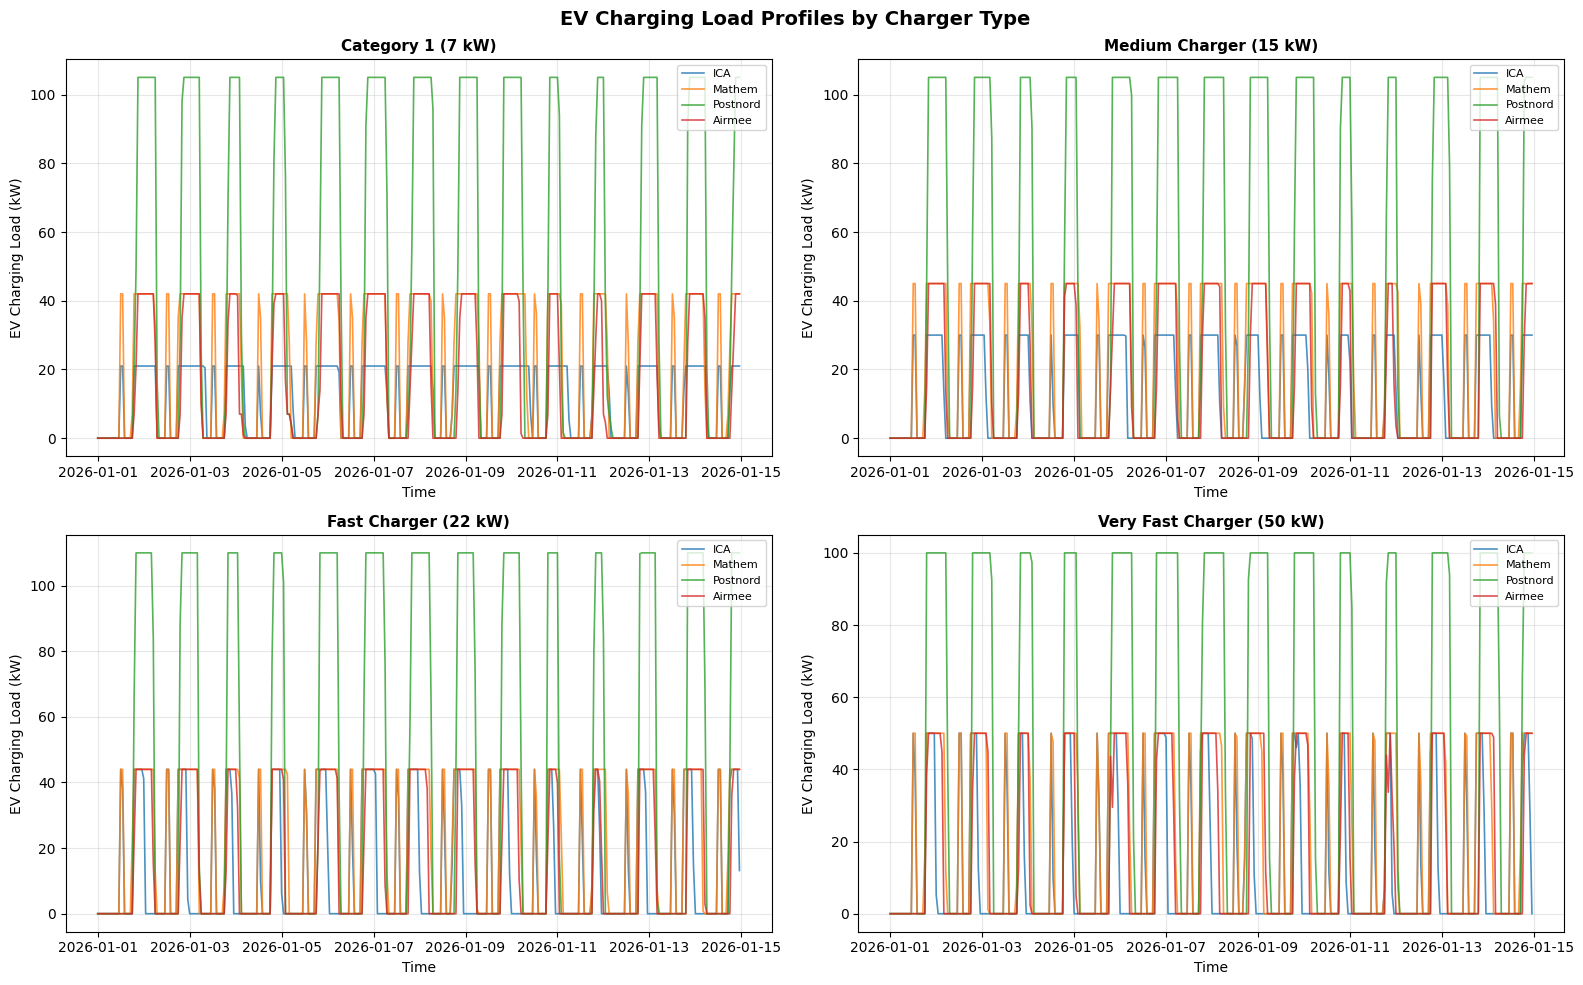

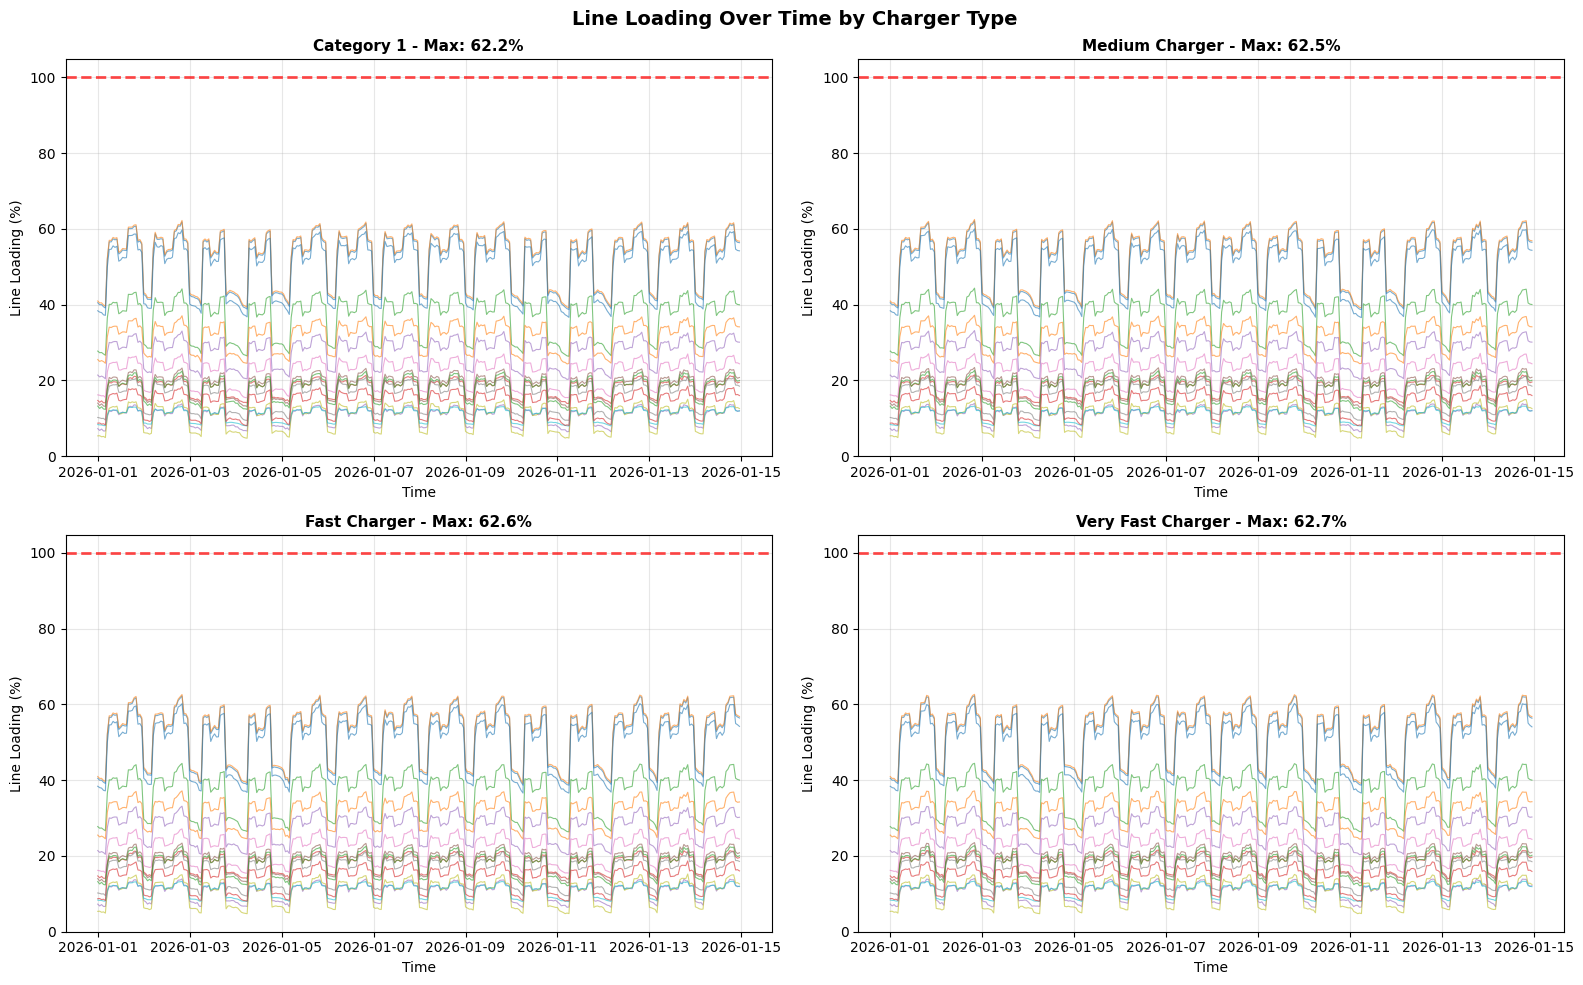

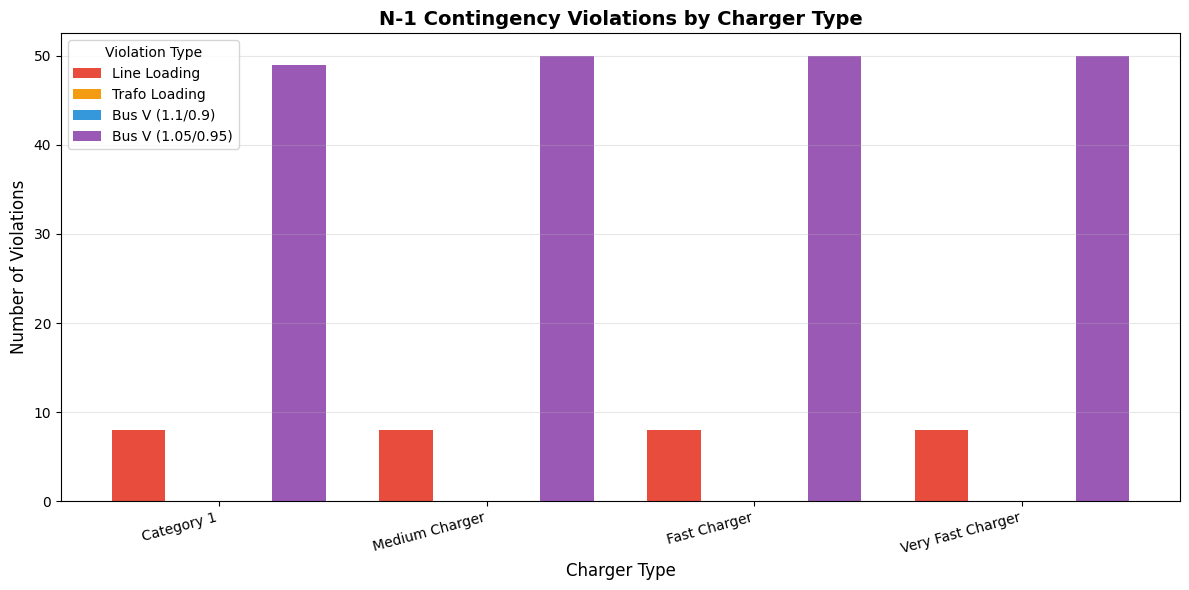

C:\Users\matis\AppData\Local\Temp\ipykernel_7336\2998061351.py:634: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


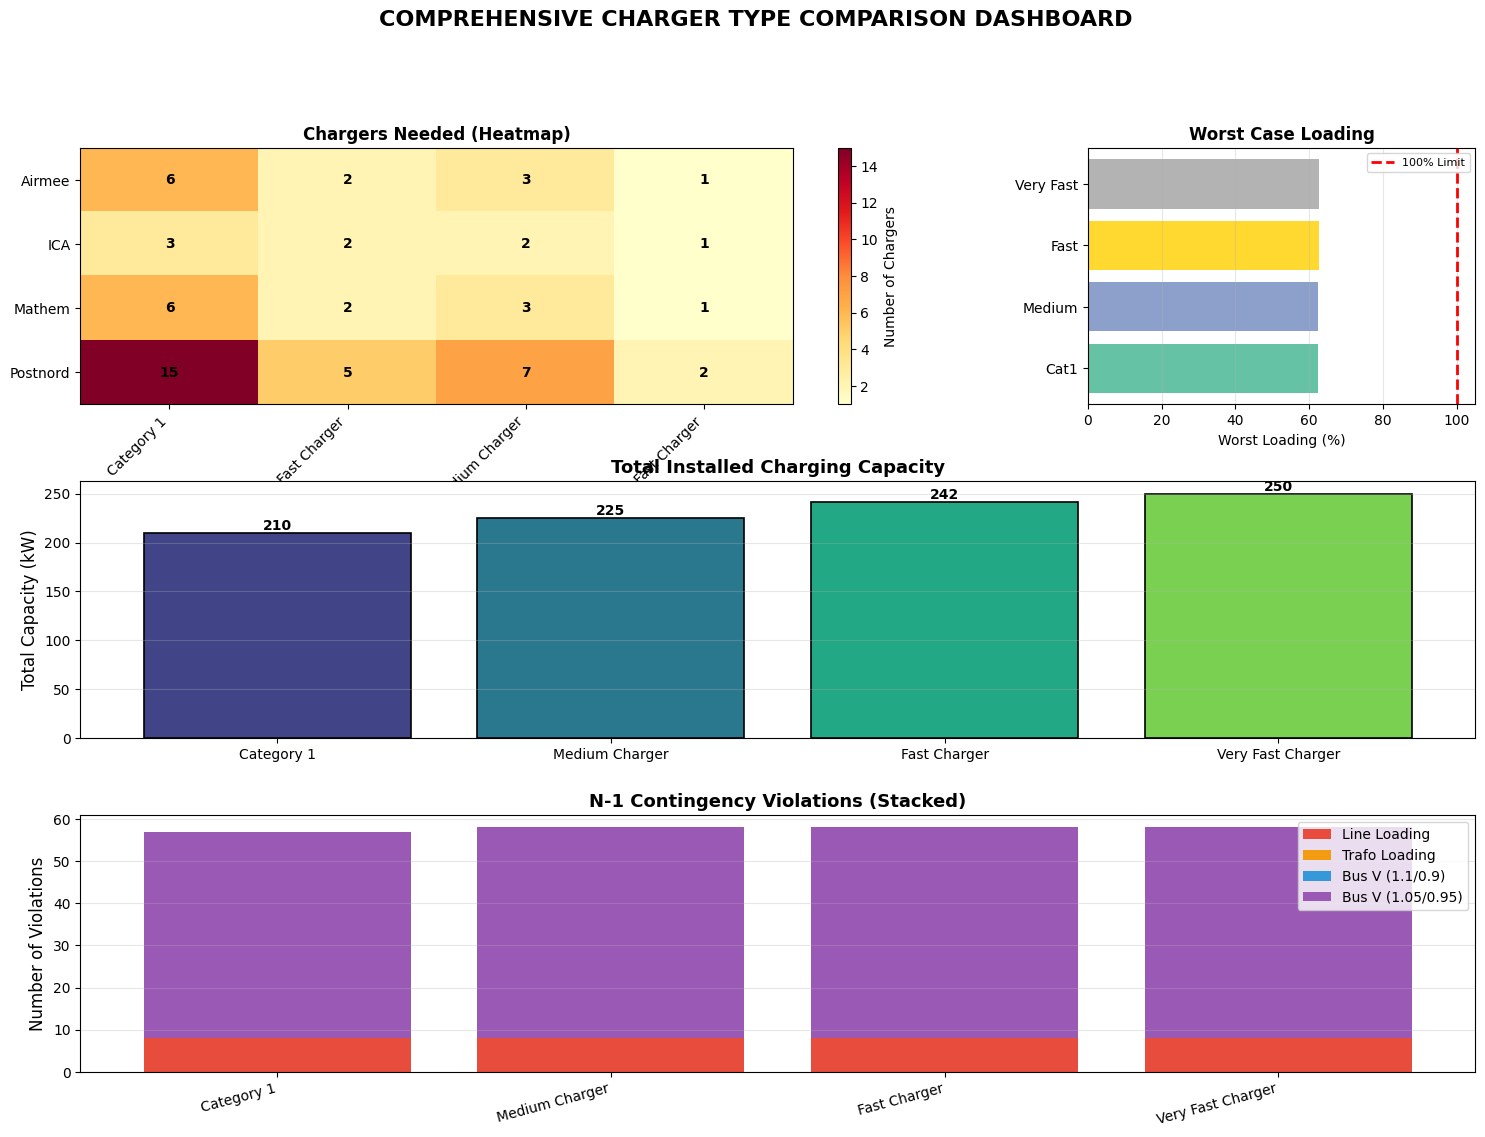

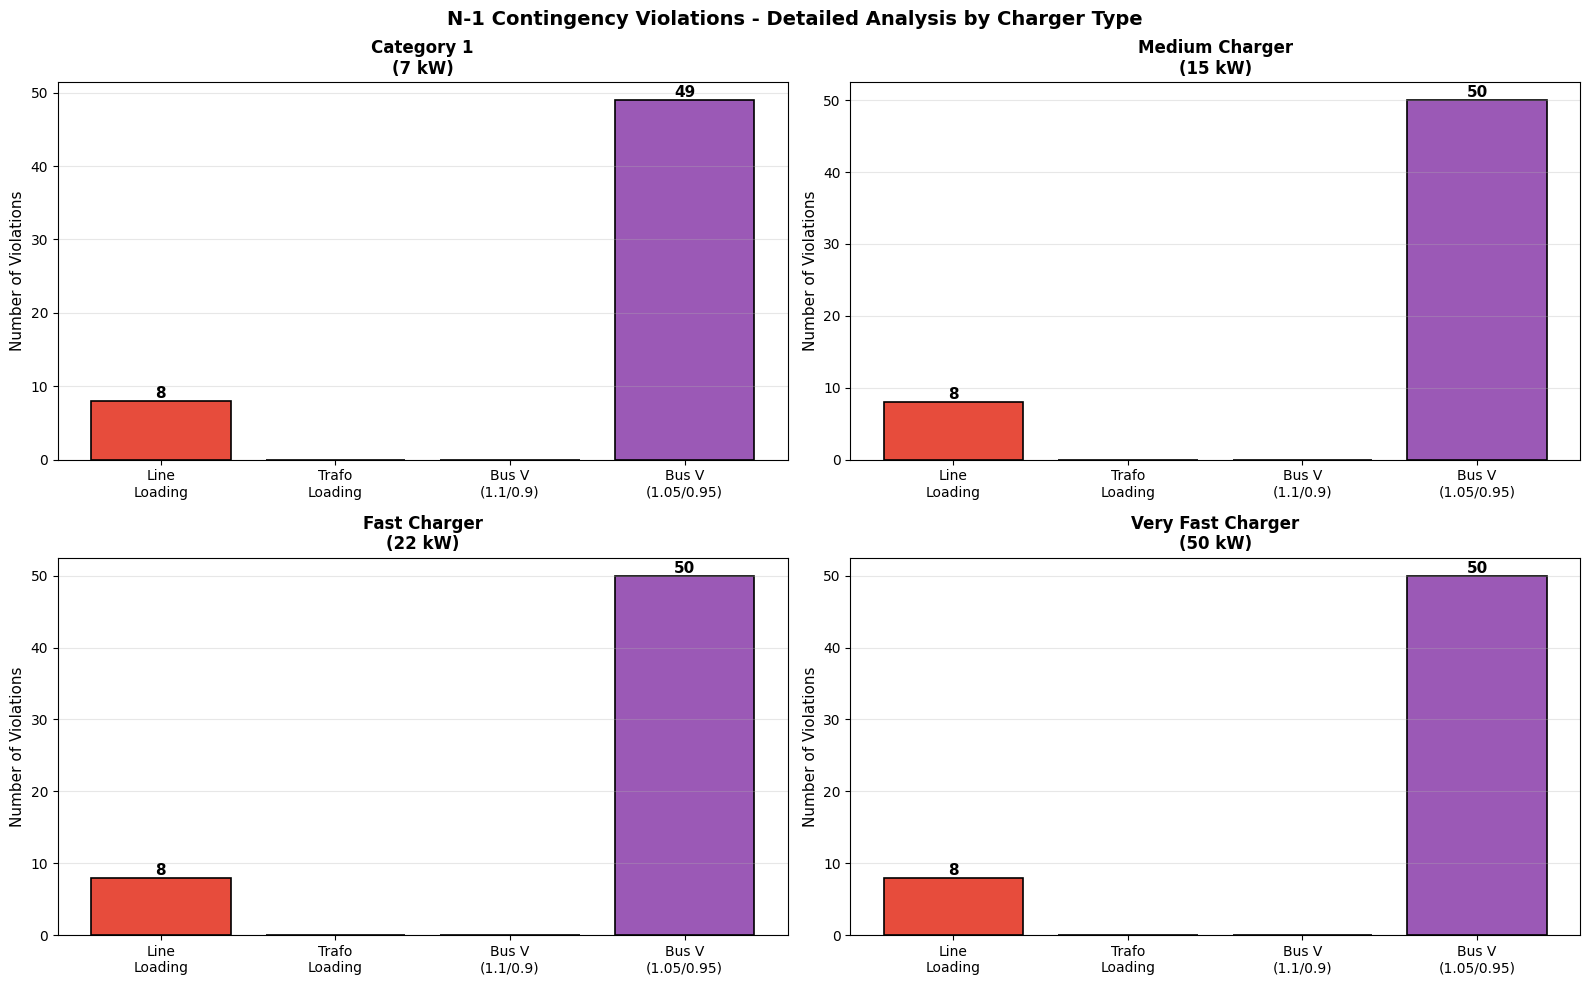

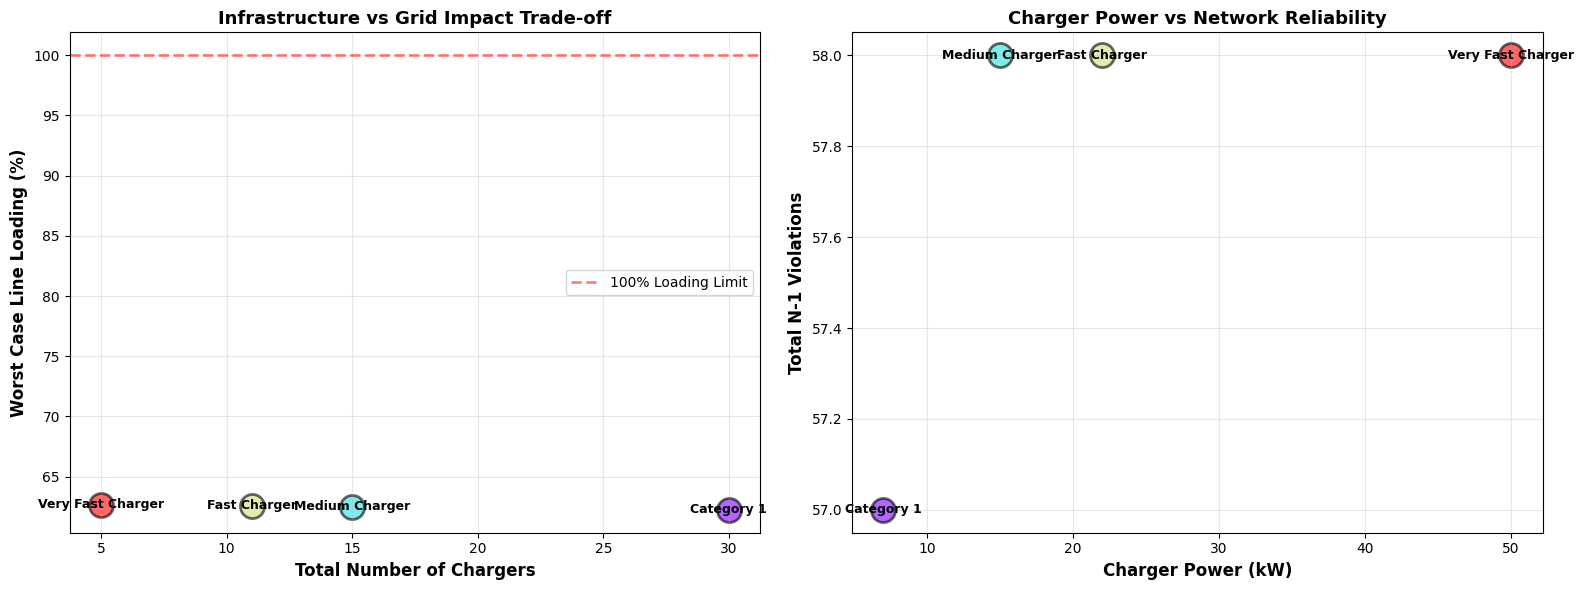

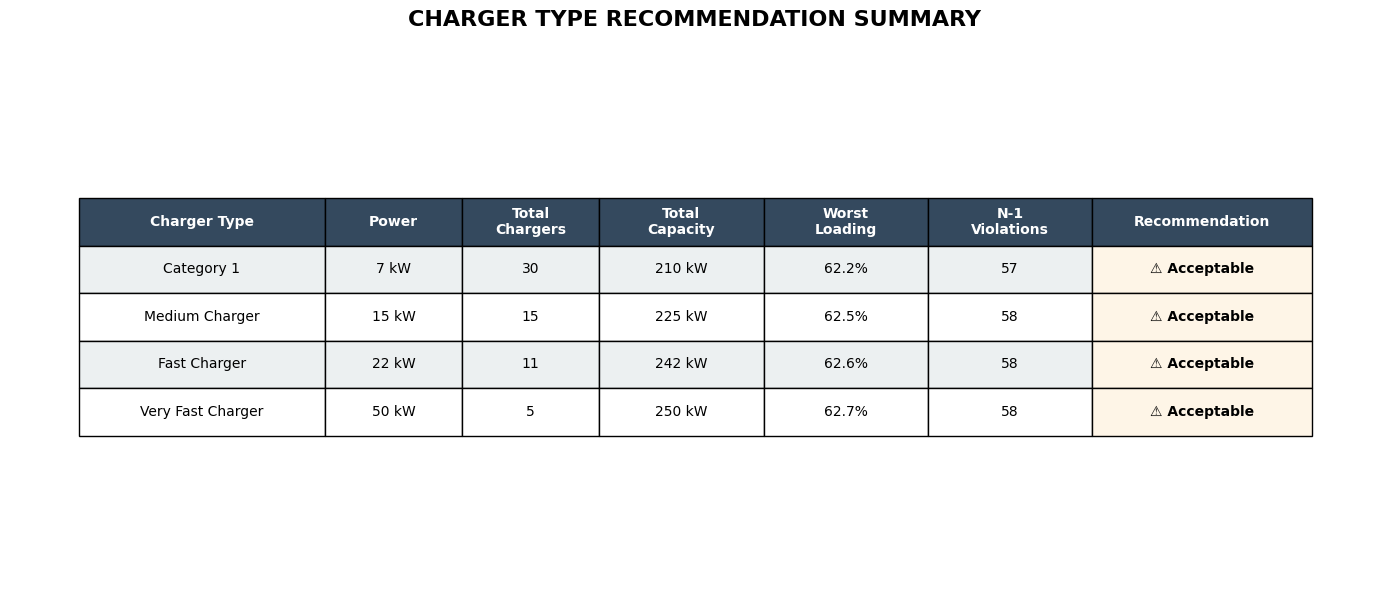


ANALYSIS COMPLETE

Key Findings:
  • Total charger types tested: 4
  • Total shops analyzed: 4
  • Simulation period: 336 hours

  • Recommended charger type: Category 1
    - Worst loading: 62.24%
    - Total N-1 violations: 57
    - Total capacity: 210 kW


In [30]:
import pandas as pd
import pandapower as pp
import pandapower.networks as nw
import pandapower.topology as top
import matplotlib.pyplot as plt
import copy
from pathlib import Path
import os
import numpy as np
import networkx as nx

# ------------- 1. Create network -------------
net0 = nw.create_cigre_network_mv(with_der=False)
net0.switch["closed"] = True
net0.load['p_mw'] = net0.load['p_mw'] / 2.0
net0.load['q_mvar'] = net0.load['q_mvar'] / 2.0
base_loads = net0.load['p_mw'].copy()

# ------------- 2. Read freight load profiles -------------
file_path = "Load_profiles_Freight transports.xlsx"
load_profile = pd.read_excel(file_path)
load_profile["Datetime"] = pd.to_datetime(
    load_profile["Date"].astype(str) + " " + load_profile["Time"].astype(str)
)
load_profile = load_profile.set_index("Datetime")
shops = ["ICA", "Mathem", "Postnord", "Airmee"]
load_profile = load_profile[shops]

# ------------- 3. EV Configuration -------------
CHARGER_TYPES = {
    "Category 1": {"power_kw": 7},
    "Medium Charger": {"power_kw": 15},
    "Fast Charger": {"power_kw": 22},
    "Very Fast Charger": {"power_kw": 50}
}

VEHICLE_SPECS = {
    "Renault": {"max_charging_kw": 80.0, "battery_kwh": 48.0},
    "Toyota": {"max_charging_kw": 100.0, "battery_kwh": 75.0}
}

notebook_dir = Path(os.getcwd())
base_path = notebook_dir.parent / "data" / "Output"

SHOP_SCHEDULES = {
    "ICA": "schedule_ICA",
    "Mathem": "schedule_Mathem",
    "Postnord": "schedule_Postnord",
    "Airmee": "schedule_Airmee"
}

# ------------- 4. EV Simulation Functions -------------
def find_min_chargers(file_path, charger_type, max_test=20):
    charger_power_kw = CHARGER_TYPES[charger_type]["power_kw"]
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    
    for num in range(1, max_test + 1):
        SOC = {vid: VEHICLE_SPECS[vehicle_types.get(vid, "Renault")]["battery_kwh"] 
               for vid in vehicles}
        unmet_energy = 0.0
        
        for ts in timestamps:
            df_h = df[df['date'] == ts]
            
            for _, row in df_h.iterrows():
                vid = row['VehicleID']
                cons = float(row.get('Consumption_kWh', 0.0))
                new_soc = SOC[vid] - cons
                if new_soc < 0:
                    unmet_energy += abs(new_soc)
                    SOC[vid] = 0.0
                else:
                    SOC[vid] = new_soc
            
            depot_rows = df_h[df_h['Location'] == 1]
            present_vids = depot_rows['VehicleID'].unique().tolist()
            available_power = num * charger_power_kw
            
            needs = []
            for vid in present_vids:
                vtype = vehicle_types.get(vid, "Renault")
                battery_cap = VEHICLE_SPECS[vtype]["battery_kwh"]
                max_inlet = VEHICLE_SPECS[vtype]["max_charging_kw"]
                need = battery_cap - SOC[vid]
                if need > 0.001:
                    needs.append({'vid': vid, 'need': need, 
                                'max_inlet': min(max_inlet, charger_power_kw)})
            
            needs.sort(key=lambda x: x['need'], reverse=True)
            for n in needs:
                if available_power <= 0.001:
                    break
                charge = min(n['need'], n['max_inlet'], available_power)
                SOC[n['vid']] += charge
                available_power -= charge
        
        if unmet_energy < 0.001:
            return num
    return None

def calculate_ev_charging_load(file_path, charger_type, num_chargers):
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    charger_power_kw = CHARGER_TYPES[charger_type]["power_kw"]
    
    SOC = {vid: VEHICLE_SPECS[vehicle_types.get(vid, "Renault")]["battery_kwh"] 
           for vid in vehicles}
    charging_loads = []
    
    for ts in timestamps:
        df_h = df[df['date'] == ts]
        
        for _, row in df_h.iterrows():
            vid = row['VehicleID']
            cons = float(row.get('Consumption_kWh', 0.0))
            SOC[vid] = max(0.0, SOC[vid] - cons)
        
        depot_rows = df_h[df_h['Location'] == 1]
        present_vids = depot_rows['VehicleID'].unique().tolist()
        
        needs = []
        for vid in present_vids:
            vtype = vehicle_types.get(vid, "Renault")
            battery_cap = VEHICLE_SPECS[vtype]["battery_kwh"]
            max_inlet = VEHICLE_SPECS[vtype]["max_charging_kw"]
            need = battery_cap - SOC[vid]
            if need > 0.001:
                needs.append({'vid': vid, 'need': need, 
                            'max_inlet': min(max_inlet, charger_power_kw)})
        
        needs.sort(key=lambda x: x['need'], reverse=True)
        available_power = num_chargers * charger_power_kw
        total_charging = 0.0
        
        for n in needs:
            if available_power <= 0.001:
                break
            charge = min(n['need'], n['max_inlet'], available_power)
            SOC[n['vid']] += charge
            total_charging += charge
            available_power -= charge
        
        charging_loads.append({'timestamp': ts, 'charging_kw': total_charging})
    
    return pd.DataFrame(charging_loads).set_index('timestamp')

# ------------- 5. Shop placements -------------
shop_to_bus = {"ICA": 13, "Mathem": 6, "Postnord": 10, "Airmee": 6}
#   shop_to_bus = {"ICA": 10, "Mathem": 10, "Postnord": 10, "Airmee": 10}

# ------------- 6. Network creation function -------------
def create_network_with_shops(net_base, shop_mapping, timestamp, ev_load_profile, freight_profile):
    net = copy.deepcopy(net_base)
    net.load['p_mw'] = base_loads.copy()
    
    ts_naive = timestamp.replace(tzinfo=None) if timestamp.tzinfo else timestamp
    
    for shop, bus in shop_mapping.items():
        freight_load_mw = freight_profile.at[timestamp, shop] / 1000.0
        
        ev_load_kw = 0.0
        if shop in ev_load_profile.columns and ts_naive in ev_load_profile.index:
            ev_load_kw = ev_load_profile.at[ts_naive, shop]
        
        total_load_mw = freight_load_mw + (ev_load_kw / 1000.0)
        
        existing_loads = net.load[net.load.bus == bus]
        if not existing_loads.empty:
            load_idx = existing_loads.index[0]
            net.load.at[load_idx, 'p_mw'] += total_load_mw
        else:
            pp.create_load(net, bus=bus, p_mw=total_load_mw, q_mvar=0)
    
    return net


# ------------- 7. N-1 Contingency Analysis -------------
def check_n1_contingency(net):
    """
    Perform N-1 contingency analysis on the network.
    Returns a dictionary with violation statistics.
    """
    violations = {
        'line_loading': [],
        'trafo_loading': [],
        'bus_voltage_1.1_0.9': [],
        'bus_voltage_1.05_0.95': []
    }
    
    num_lines = len(net.line)
    
    for i in range(num_lines):
        # Take line out of service
        net.line.loc[i, "in_service"] = False
        net.switch["closed"] = True
        
        # Build networkx graph and MST
        G = top.create_nxgraph(net, respect_switches=True)
        mst = nx.minimum_spanning_tree(G)
        
        # Open switches not in MST
        for j, sw in net.switch.iterrows():
            b1 = sw.bus
            if sw.et == "l":
                line_bus = net.line.at[sw.element, "from_bus"] if net.line.at[sw.element, "from_bus"] != b1 else net.line.at[sw.element, "to_bus"]
                if not mst.has_edge(b1, line_bus):
                    net.switch.at[j, "closed"] = False
        
        # Run power flow
        try:
            pp.runpp(net)
            
            # Check line loading
            for line_id, loading in net.res_line.loading_percent.items():
                if loading > 100:
                    violations['line_loading'].append({
                        'contingency_line': i,
                        'violated_line': line_id,
                        'loading': loading
                    })
            
            # Check trafo loading
            for trafo_id, loading in net.res_trafo.loading_percent.items():
                if loading > 100:
                    violations['trafo_loading'].append({
                        'contingency_line': i,
                        'violated_trafo': trafo_id,
                        'loading': loading
                    })
            
            # Check bus voltage (1.1/0.9)
            for bus_id, voltage in net.res_bus.vm_pu.items():
                if voltage > 1.1 or voltage < 0.9:
                    violations['bus_voltage_1.1_0.9'].append({
                        'contingency_line': i,
                        'violated_bus': bus_id,
                        'voltage': voltage
                    })
            
            # Check bus voltage (1.05/0.95)
            for bus_id, voltage in net.res_bus.vm_pu.items():
                if voltage > 1.05 or voltage < 0.95:
                    violations['bus_voltage_1.05_0.95'].append({
                        'contingency_line': i,
                        'violated_bus': bus_id,
                        'voltage': voltage
                    })
        
        except:
            print(f"    Warning: Power flow failed for line {i} contingency")
        
        # Restore line
        net.line.loc[i, "in_service"] = True
    
    return violations

def run_simulation_for_charger_type(charger_type, shops_to_test):
    """Run complete simulation for a specific charger type"""
    print(f"\n{'='*60}")
    print(f"Testing Charger Type: {charger_type} ({CHARGER_TYPES[charger_type]['power_kw']} kW)")
    print(f"{'='*60}")
    
    # Generate EV load profile for this charger type
    ev_load_profile = pd.DataFrame()
    charger_counts = {}
    
    for shop, schedule_name in SHOP_SCHEDULES.items():
        file_path = base_path / schedule_name / f"{schedule_name}.csv"
        
        if not file_path.exists():
            print(f"  Warning: {file_path} not found")
            continue
        
        num_chargers = find_min_chargers(file_path, charger_type)
        if num_chargers is None:
            print(f"  Warning: {shop} not feasible with {charger_type}")
            charger_counts[shop] = None
            continue
        
        charger_counts[shop] = num_chargers
        print(f"  {shop}: {num_chargers} chargers needed")
        
        load_df = calculate_ev_charging_load(file_path, charger_type, num_chargers)
        ev_load_profile[shop] = load_df['charging_kw']
    
    ev_load_profile = ev_load_profile.fillna(0)
    
    # Align timestamps
    ev_load_profile.index = ev_load_profile.index.tz_localize(None)
    ev_start = ev_load_profile.index[0]
    freight_start = load_profile.index[0]
    time_diff = freight_start - ev_start.tz_localize(freight_start.tz)
    ev_load_profile.index = ev_load_profile.index + time_diff
    
    # Run power flow simulations
    line_indices = list(net0.line.index)
    res_lines = pd.DataFrame(index=load_profile.index, 
                            columns=[f"line_{i}" for i in line_indices], dtype=float)
    
    print(f"\n  Running power flow simulations...")
    for ts_idx, ts in enumerate(load_profile.index):
        if ts_idx % 48 == 0:
            print(f"    Progress: {ts_idx}/{len(load_profile.index)} timesteps")
        
        net = create_network_with_shops(net0, shop_to_bus, ts, ev_load_profile, load_profile)
        pp.runpp(net, calculate_voltage_angles=False)
        
        for li in line_indices:
            res_lines.at[ts, f"line_{li}"] = net.res_line.loading_percent.at[li]
    
    worst_loading = res_lines.max().max()
    print(f"\n  Worst case line loading: {worst_loading:.2f}%")
    
    # Find worst case timestamp
    worst_line = res_lines.max().idxmax()
    worst_ts = res_lines[worst_line].idxmax()
    print(f"  Worst case occurs at: {worst_ts} on {worst_line}")
    
    # N-1 contingency analysis at worst case
    print(f"\n  Performing N-1 contingency analysis at worst case...")
    net_worst = create_network_with_shops(net0, shop_to_bus, worst_ts, ev_load_profile, load_profile)
    violations = check_n1_contingency(net_worst)
    
    print(f"    Line loading violations: {len(violations['line_loading'])}")
    print(f"    Trafo loading violations: {len(violations['trafo_loading'])}")
    print(f"    Bus voltage violations (1.1/0.9): {len(violations['bus_voltage_1.1_0.9'])}")
    print(f"    Bus voltage violations (1.05/0.95): {len(violations['bus_voltage_1.05_0.95'])}")
    
    return {
        'charger_type': charger_type,
        'charger_counts': charger_counts,
        'worst_loading': worst_loading,
        'worst_timestamp': worst_ts,
        'ev_load_profile': ev_load_profile,
        'line_loading': res_lines,
        'n1_violations': violations
    }

# ------------- 7. Run all charger type tests -------------
print("="*60)
print("COMPREHENSIVE CHARGER TYPE ANALYSIS")
print("="*60)

all_results = {}
for charger_type in CHARGER_TYPES.keys():
    result = run_simulation_for_charger_type(charger_type, shops)
    all_results[charger_type] = result

# ------------- 8. Create comparison summary -------------
print("\n" + "="*60)
print("SUMMARY COMPARISON")
print("="*60)

summary_data = []
for charger_type, result in all_results.items():
    for shop in shops:
        count = result['charger_counts'].get(shop, 'N/A')
        summary_data.append({
            'Charger Type': charger_type,
            'Power (kW)': CHARGER_TYPES[charger_type]['power_kw'],
            'Shop': shop,
            'Num Chargers': count,
            'Worst Loading (%)': result['worst_loading']
        })

summary_df = pd.DataFrame(summary_data)
print("\nDetailed Results:")
print(summary_df.to_string(index=False))

# Pivot tables for easier comparison
print("\n" + "-"*60)
print("CHARGERS NEEDED PER SHOP")
print("-"*60)
charger_pivot = summary_df.pivot_table(
    index='Shop', 
    columns='Charger Type', 
    values='Num Chargers', 
    aggfunc='first'
)
print(charger_pivot)

print("\n" + "-"*60)
print("WORST CASE LINE LOADING (%)")
print("-"*60)
worst_loading_summary = summary_df.groupby('Charger Type')['Worst Loading (%)'].first()
print(worst_loading_summary)

# N-1 Violation Summary
print("\n" + "-"*60)
print("N-1 CONTINGENCY VIOLATIONS SUMMARY")
print("-"*60)
n1_summary = []
for charger_type, result in all_results.items():
    viol = result['n1_violations']
    n1_summary.append({
        'Charger Type': charger_type,
        'Line Loading': len(viol['line_loading']),
        'Trafo Loading': len(viol['trafo_loading']),
        'Bus V (1.1/0.9)': len(viol['bus_voltage_1.1_0.9']),
        'Bus V (1.05/0.95)': len(viol['bus_voltage_1.05_0.95'])
    })
n1_df = pd.DataFrame(n1_summary)
print(n1_df.to_string(index=False))

# ------------- 9. Visualizations -------------

# 1. Number of chargers needed per shop (grouped bar chart)
fig, ax = plt.subplots(figsize=(12, 6))
charger_pivot_plot = charger_pivot.T
x = np.arange(len(shops))
width = 0.2
colors = plt.cm.Set3(np.linspace(0, 1, len(CHARGER_TYPES)))

for i, (charger_type, color) in enumerate(zip(CHARGER_TYPES.keys(), colors)):
    values = [charger_pivot.loc[shop, charger_type] if shop in charger_pivot.index else 0 
              for shop in shops]
    ax.bar(x + i*width, values, width, label=charger_type, color=color)

ax.set_xlabel('Shop', fontsize=12)
ax.set_ylabel('Number of Chargers', fontsize=12)
ax.set_title('Chargers Required by Shop and Charger Type', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(shops)
ax.legend(title='Charger Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Worst case line loading comparison
fig, ax = plt.subplots(figsize=(10, 6))
charger_names = list(all_results.keys())
worst_loadings = [all_results[ct]['worst_loading'] for ct in charger_names]
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(charger_names)))

bars = ax.bar(charger_names, worst_loadings, color=colors_bar, edgecolor='black', linewidth=1.2)
ax.axhline(y=100, color='red', linestyle='--', linewidth=2, label='100% Loading Limit')
ax.set_ylabel('Worst Case Line Loading (%)', fontsize=12)
ax.set_xlabel('Charger Type', fontsize=12)
ax.set_title('Worst Case Line Loading by Charger Type', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend()

for bar, loading in zip(bars, worst_loadings):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{loading:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Total installed capacity comparison
fig, ax = plt.subplots(figsize=(10, 6))
total_capacity = {}
for charger_type, result in all_results.items():
    total_kw = sum([
        result['charger_counts'].get(shop, 0) * CHARGER_TYPES[charger_type]['power_kw']
        for shop in shops if result['charger_counts'].get(shop) is not None
    ])
    total_capacity[charger_type] = total_kw

charger_names = list(total_capacity.keys())
capacities = list(total_capacity.values())
colors_cap = plt.cm.plasma(np.linspace(0.2, 0.8, len(charger_names)))

bars = ax.bar(charger_names, capacities, color=colors_cap, edgecolor='black', linewidth=1.2)
ax.set_ylabel('Total Installed Capacity (kW)', fontsize=12)
ax.set_xlabel('Charger Type', fontsize=12)
ax.set_title('Total Charging Infrastructure Capacity by Charger Type', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, cap in zip(bars, capacities):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{cap:.0f} kW', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. EV charging load profiles comparison (one charger type, all shops)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (charger_type, result) in enumerate(all_results.items()):
    ax = axes[idx]
    ev_profile = result['ev_load_profile']
    
    for shop in shops:
        if shop in ev_profile.columns:
            ax.plot(ev_profile.index, ev_profile[shop], 
                   linewidth=1.2, label=f"{shop}", alpha=0.8)
    
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('EV Charging Load (kW)', fontsize=10)
    ax.set_title(f'{charger_type} ({CHARGER_TYPES[charger_type]["power_kw"]} kW)', 
                fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('EV Charging Load Profiles by Charger Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Line loading time series for each charger type
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (charger_type, result) in enumerate(all_results.items()):
    ax = axes[idx]
    line_loading = result['line_loading']
    
    for col in line_loading.columns:
        ax.plot(line_loading.index, line_loading[col], 
               linewidth=0.8, alpha=0.6)
    
    ax.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Line Loading (%)', fontsize=10)
    ax.set_title(f'{charger_type} - Max: {result["worst_loading"]:.1f}%', 
                fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Line Loading Over Time by Charger Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. N-1 Contingency Violations Comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_results))
width = 0.2

violation_types = ['Line Loading', 'Trafo Loading', 'Bus V (1.1/0.9)', 'Bus V (1.05/0.95)']
colors_viol = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']

for i, (vtype, color) in enumerate(zip(violation_types, colors_viol)):
    values = [len(all_results[ct]['n1_violations'][k]) 
              for ct in all_results.keys()
              for k in [['line_loading', 'trafo_loading', 'bus_voltage_1.1_0.9', 'bus_voltage_1.05_0.95'][i]]]
    ax.bar(x + i*width, values, width, label=vtype, color=color)

ax.set_xlabel('Charger Type', fontsize=12)
ax.set_ylabel('Number of Violations', fontsize=12)
ax.set_title('N-1 Contingency Violations by Charger Type', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(all_results.keys(), rotation=15, ha='right')
ax.legend(title='Violation Type')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Comprehensive Comparison Dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Top left: Chargers needed heatmap
ax1 = fig.add_subplot(gs[0, :2])
charger_pivot_filled = charger_pivot.fillna(0)
im = ax1.imshow(charger_pivot_filled.values, cmap='YlOrRd', aspect='auto')
ax1.set_xticks(np.arange(len(charger_pivot_filled.columns)))
ax1.set_yticks(np.arange(len(charger_pivot_filled.index)))
ax1.set_xticklabels(charger_pivot_filled.columns, rotation=45, ha='right')
ax1.set_yticklabels(charger_pivot_filled.index)
ax1.set_title('Chargers Needed (Heatmap)', fontweight='bold')
for i in range(len(charger_pivot_filled.index)):
    for j in range(len(charger_pivot_filled.columns)):
        val = charger_pivot_filled.iloc[i, j]
        text = ax1.text(j, i, f'{int(val)}' if val > 0 else '-',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax1, label='Number of Chargers')

# Top right: Worst loading
ax2 = fig.add_subplot(gs[0, 2])
charger_names_short = [ct.replace(' Charger', '').replace('Category ', 'Cat') 
                       for ct in all_results.keys()]
worst_loadings = [all_results[ct]['worst_loading'] for ct in all_results.keys()]
colors_pie = plt.cm.Set2(np.linspace(0, 1, len(charger_names_short)))
bars = ax2.barh(charger_names_short, worst_loadings, color=colors_pie)
ax2.axvline(x=100, color='red', linestyle='--', linewidth=2, label='100% Limit')
ax2.set_xlabel('Worst Loading (%)', fontsize=10)
ax2.set_title('Worst Case Loading', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

# Middle: Total capacity
ax3 = fig.add_subplot(gs[1, :])
charger_names = list(total_capacity.keys())
capacities = list(total_capacity.values())
colors_capacity = plt.cm.viridis(np.linspace(0.2, 0.8, len(charger_names)))
bars = ax3.bar(charger_names, capacities, color=colors_capacity, edgecolor='black', linewidth=1.2)
ax3.set_ylabel('Total Capacity (kW)', fontsize=12)
ax3.set_title('Total Installed Charging Capacity', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for bar, cap in zip(bars, capacities):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{cap:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Bottom: N-1 violations stacked
ax4 = fig.add_subplot(gs[2, :])
charger_names = list(all_results.keys())
line_viols = [len(all_results[ct]['n1_violations']['line_loading']) for ct in charger_names]
trafo_viols = [len(all_results[ct]['n1_violations']['trafo_loading']) for ct in charger_names]
bus_11_viols = [len(all_results[ct]['n1_violations']['bus_voltage_1.1_0.9']) for ct in charger_names]
bus_05_viols = [len(all_results[ct]['n1_violations']['bus_voltage_1.05_0.95']) for ct in charger_names]

x_pos = np.arange(len(charger_names))
ax4.bar(x_pos, line_viols, label='Line Loading', color='#e74c3c')
ax4.bar(x_pos, trafo_viols, bottom=line_viols, label='Trafo Loading', color='#f39c12')
bottom2 = [line_viols[i] + trafo_viols[i] for i in range(len(charger_names))]
ax4.bar(x_pos, bus_11_viols, bottom=bottom2, label='Bus V (1.1/0.9)', color='#3498db')
bottom3 = [bottom2[i] + bus_11_viols[i] for i in range(len(charger_names))]
ax4.bar(x_pos, bus_05_viols, bottom=bottom3, label='Bus V (1.05/0.95)', color='#9b59b6')

ax4.set_xticks(x_pos)
ax4.set_xticklabels(charger_names, rotation=15, ha='right')
ax4.set_ylabel('Number of Violations', fontsize=12)
ax4.set_title('N-1 Contingency Violations (Stacked)', fontsize=13, fontweight='bold')
ax4.legend(loc='upper right')
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('COMPREHENSIVE CHARGER TYPE COMPARISON DASHBOARD', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 8. Detailed N-1 Violation Analysis per Charger Type
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (charger_type, result) in enumerate(all_results.items()):
    ax = axes[idx]
    viol = result['n1_violations']
    
    categories = ['Line\nLoading', 'Trafo\nLoading', 'Bus V\n(1.1/0.9)', 'Bus V\n(1.05/0.95)']
    counts = [
        len(viol['line_loading']),
        len(viol['trafo_loading']),
        len(viol['bus_voltage_1.1_0.9']),
        len(viol['bus_voltage_1.05_0.95'])
    ]
    colors_detail = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']
    
    bars = ax.bar(categories, counts, color=colors_detail, edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Number of Violations', fontsize=11)
    ax.set_title(f'{charger_type}\n({CHARGER_TYPES[charger_type]["power_kw"]} kW)', 
                fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        if count > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(count)}', ha='center', va='bottom', 
                   fontsize=11, fontweight='bold')

plt.suptitle('N-1 Contingency Violations - Detailed Analysis by Charger Type', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 9. Economic and Technical Trade-off Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Infrastructure cost vs Grid impact
charger_names = list(all_results.keys())
total_chargers = [sum([result['charger_counts'].get(shop, 0) 
                      for shop in shops if result['charger_counts'].get(shop) is not None])
                 for result in all_results.values()]
worst_loadings = [all_results[ct]['worst_loading'] for ct in charger_names]

colors_scatter = plt.cm.rainbow(np.linspace(0, 1, len(charger_names)))
for i, (ct, tc, wl, color) in enumerate(zip(charger_names, total_chargers, worst_loadings, colors_scatter)):
    ax1.scatter(tc, wl, s=300, alpha=0.6, color=color, edgecolor='black', linewidth=2)
    ax1.annotate(ct, (tc, wl), fontsize=9, ha='center', va='center', fontweight='bold')

ax1.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.5, label='100% Loading Limit')
ax1.set_xlabel('Total Number of Chargers', fontsize=12, fontweight='bold')
ax1.set_ylabel('Worst Case Line Loading (%)', fontsize=12, fontweight='bold')
ax1.set_title('Infrastructure vs Grid Impact Trade-off', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Right: Capacity efficiency (kW per charger vs violations)
avg_power = [CHARGER_TYPES[ct]['power_kw'] for ct in charger_names]
total_violations = [sum([len(all_results[ct]['n1_violations'][k]) 
                        for k in all_results[ct]['n1_violations'].keys()])
                   for ct in charger_names]

for i, (ct, ap, tv, color) in enumerate(zip(charger_names, avg_power, total_violations, colors_scatter)):
    ax2.scatter(ap, tv, s=300, alpha=0.6, color=color, edgecolor='black', linewidth=2)
    ax2.annotate(ct, (ap, tv), fontsize=9, ha='center', va='center', fontweight='bold')

ax2.set_xlabel('Charger Power (kW)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total N-1 Violations', fontsize=12, fontweight='bold')
ax2.set_title('Charger Power vs Network Reliability', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Summary recommendation table visualization
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.axis('off')

# Create summary recommendation data
recommendation_data = []
for charger_type in all_results.keys():
    result = all_results[charger_type]
    total_ch = sum([result['charger_counts'].get(shop, 0) 
                   for shop in shops if result['charger_counts'].get(shop) is not None])
    total_cap = total_capacity[charger_type]
    worst_load = result['worst_loading']
    total_viol = sum([len(result['n1_violations'][k]) for k in result['n1_violations'].keys()])
    
    # Recommendation logic
    if worst_load < 100 and total_viol == 0:
        recommendation = "✓ Excellent"
        color = '#2ecc71'
    elif worst_load < 100 and total_viol < 10:
        recommendation = "✓ Good"
        color = '#3498db'
    elif worst_load < 110:
        recommendation = "⚠ Acceptable"
        color = '#f39c12'
    else:
        recommendation = "✗ Not Recommended"
        color = '#e74c3c'
    
    recommendation_data.append([
        charger_type,
        f"{CHARGER_TYPES[charger_type]['power_kw']} kW",
        f"{total_ch}",
        f"{total_cap:.0f} kW",
        f"{worst_load:.1f}%",
        f"{total_viol}",
        recommendation
    ])

table = ax.table(cellText=recommendation_data,
                colLabels=['Charger Type', 'Power', 'Total\nChargers', 'Total\nCapacity', 
                          'Worst\nLoading', 'N-1\nViolations', 'Recommendation'],
                cellLoc='center',
                loc='center',
                colWidths=[0.18, 0.10, 0.10, 0.12, 0.12, 0.12, 0.16])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color code the header
for i in range(7):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color code the recommendation column
for i in range(len(recommendation_data)):
    rec_text = recommendation_data[i][6]
    if '✓ Excellent' in rec_text:
        color = '#d5f4e6'
    elif '✓ Good' in rec_text:
        color = '#d6eaf8'
    elif '⚠' in rec_text:
        color = '#fef5e7'
    else:
        color = '#fadbd8'
    table[(i+1, 6)].set_facecolor(color)
    table[(i+1, 6)].set_text_props(weight='bold')

# Alternate row colors for better readability
for i in range(len(recommendation_data)):
    for j in range(6):
        if i % 2 == 0:
            table[(i+1, j)].set_facecolor('#ecf0f1')
        else:
            table[(i+1, j)].set_facecolor('#ffffff')

ax.set_title('CHARGER TYPE RECOMMENDATION SUMMARY', 
            fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print("\nKey Findings:")
print(f"  • Total charger types tested: {len(all_results)}")
print(f"  • Total shops analyzed: {len(shops)}")
print(f"  • Simulation period: {len(load_profile)} hours")

best_charger = min(all_results.items(), 
                  key=lambda x: (x[1]['worst_loading'] > 100, 
                                sum([len(x[1]['n1_violations'][k]) for k in x[1]['n1_violations'].keys()]),
                                -x[1]['worst_loading']))
print(f"\n  • Recommended charger type: {best_charger[0]}")
print(f"    - Worst loading: {best_charger[1]['worst_loading']:.2f}%")
print(f"    - Total N-1 violations: {sum([len(best_charger[1]['n1_violations'][k]) for k in best_charger[1]['n1_violations'].keys()])}")
print(f"    - Total capacity: {total_capacity[best_charger[0]]:.0f} kW")

Step 5 Instructions: to minimise the losses we need to have all the lines have the least Current possible (more balanced network)=> Minimise the Current on all the lines. We need to change the scheduler of the charging for this.  (Pandapower has a loss value )=> can also be used 